# M2A10 - Modelos Pré-Treinados

Na prática de hoje vamos utilizar modelos de aprendizado profundo pré-treinados, e para isso vamos utilizar [PyTorch](https://pytorch.org/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Modelos Pré-treinados
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install torch torchvision

Defaulting to user installation because normal site-packages is not writeable


Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision

In [3]:
image = cv2.imread("../assets/dog.jpeg")

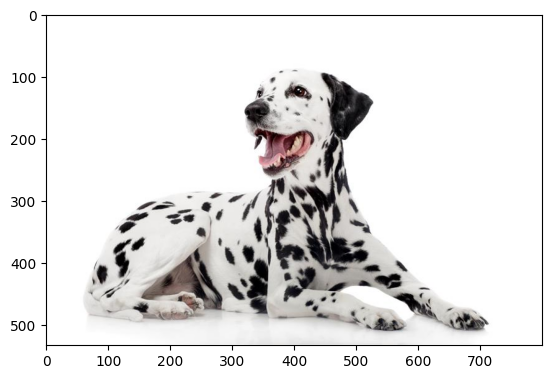

In [4]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

## Modelos Pré-Treinados

A primeira coisa para utilizar modelos pré-treinados é carregar seus pesos pré-treinados, utilizamos a biblioteca PyTorch para isso.

In [5]:
# Definindo os pesos a serem utilizados.
weights = torchvision.models.VGG16_Weights.DEFAULT

# Carregar os labels do dataset.
imagenet_labels = weights.meta["categories"] 

# Carregar o modelo.
vgg_16_model = torchvision.models.vgg16(weights)

# Criando o pipeline de transformações de pré-processamento dos dados.
preprocess = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

/Users/larry/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


In [6]:
# Vamos colocar o modelo em modo de avaliação.
vgg_16_model.eval()


# Pré processando a imagem.
image_tensor = preprocess(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
input_batch = image_tensor.unsqueeze(0) 


In [7]:
# Escolhendo o dispositivo a ser utilizado GPU se disponível.
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    vgg_16_model.to('cuda')

# Rodando a inferência.
with torch.no_grad():
    output = vgg_16_model(input_batch)

# Calculando as probabilidades das classes.
probabilities = torch.nn.functional.softmax(output[0], dim=0)

Classe predita para imagem: dalmatian


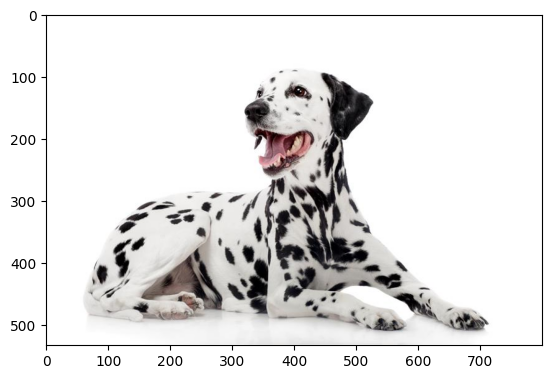

In [8]:
# Validando a classe prevista.
print(f"Classe predita para imagem: {imagenet_labels[torch.argmax(probabilities)]}")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'EntleBucher'),
  Text(1, 0, 'boxer'),
  Text(2, 0, 'American Staffordshire terrier'),
  Text(3, 0, 'kuvasz'),
  Text(4, 0, 'bluetick'),
  Text(5, 0, 'muzzle'),
  Text(6, 0, 'German short-haired pointer'),
  Text(7, 0, 'English setter'),
  Text(8, 0, 'Great Dane'),
  Text(9, 0, 'dalmatian')])

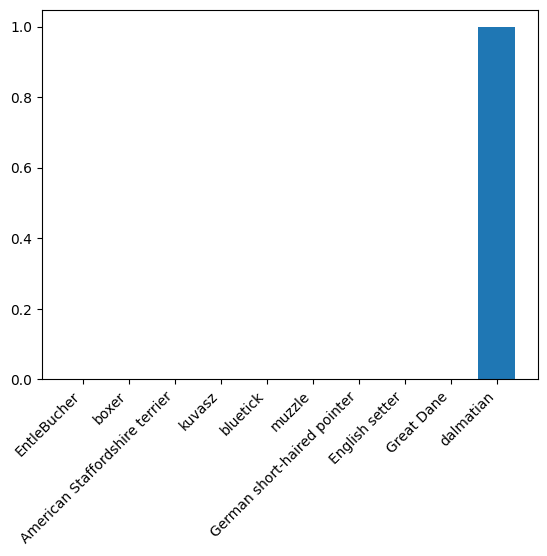

In [9]:
# Criar conjunto de labels e probabilidades, e ordenar.
set_labels_probs = list(zip(imagenet_labels, list(probabilities.cpu().numpy())))
set_labels_probs = sorted(set_labels_probs, key=lambda x: x[1])

# Pega as N classes mais prováveis.
num = 10
most_probable_classes = set_labels_probs[-num:]

# Criar as listas para o plot.
labels, probs = zip(*most_probable_classes)

# Observando as probabilidades.
plt.bar(labels, probs)
plt.xticks(rotation=45, ha='right') # Rotate labels by 45 degrees and align right


E assim terminamos a prática de hoje.

## Próximos Passos e Referências

Nas próximas práticas iremo avançar ainda mais no mundo de Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opicional)

- [x] Rode a inferência com outra imagem.
- [x] Tente utilizar outro modelo pré-treinado da mesma forma que utilizamos o modelo VGG 16.

### Atividade 1 — Testando com outra imagem

Para essa atividade, vou usar uma segunda foto de cachorro (um border collie) e ver o que o VGG-16 classifica. A ideia é checar se o modelo acerta mesmo mudando a raça.

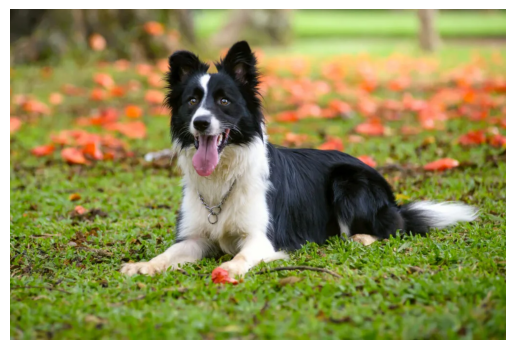

In [10]:
dog2 = cv2.imread("../assets/modulo2/border-collie.jpeg")
plt.imshow(cv2.cvtColor(dog2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Classe predita: Border collie


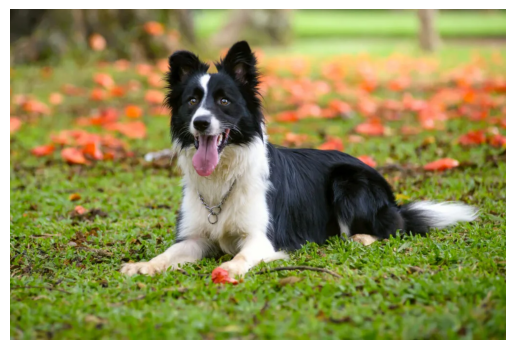

In [11]:
dog2_tensor = preprocess(cv2.cvtColor(dog2, cv2.COLOR_BGR2RGB))
dog2_batch = dog2_tensor.unsqueeze(0)

with torch.no_grad():
    dog2_output = vgg_16_model(dog2_batch)

dog2_probs = torch.nn.functional.softmax(dog2_output[0], dim=0)

print(f"Classe predita: {imagenet_labels[torch.argmax(dog2_probs)]}")
plt.imshow(cv2.cvtColor(dog2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

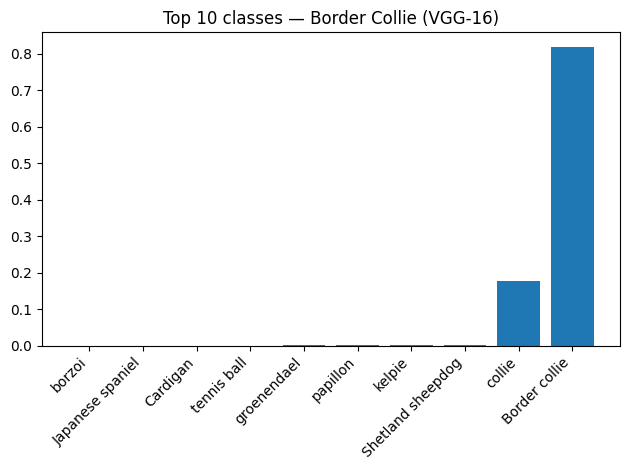

In [12]:
set_labels_probs_dog2 = list(zip(imagenet_labels, list(dog2_probs.cpu().numpy())))
set_labels_probs_dog2 = sorted(set_labels_probs_dog2, key=lambda x: x[1])

labels_dog2, probs_dog2 = zip(*set_labels_probs_dog2[-10:])

plt.bar(labels_dog2, probs_dog2)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 classes — Border Collie (VGG-16)")
plt.tight_layout()
plt.show()

### Atividade 2 — Testando com outro modelo: ResNet-50

O ResNet-50 é uma outra rede clássica treinada no ImageNet. Ela é mais profunda que o VGG-16, mas usa blocos residuais pra evitar o problema de gradiente desaparecendo — e com isso consegue ter bem menos parâmetros no total. A API do torchvision é praticamente a mesma, então a troca de modelo é quase trivial.

In [13]:
resnet_weights = torchvision.models.ResNet50_Weights.DEFAULT
resnet_labels = resnet_weights.meta["categories"]
resnet_model = torchvision.models.resnet50(resnet_weights)

resnet_preprocess = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

resnet_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

ResNet-50 prediu: Border collie


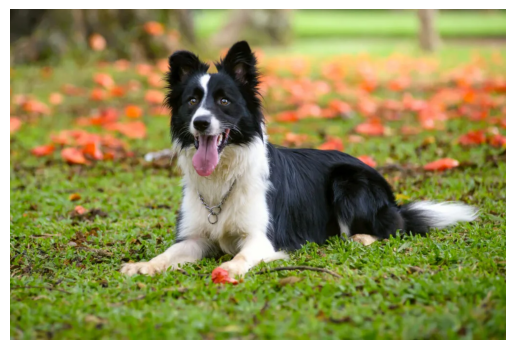

In [14]:
dog2_tensor_resnet = resnet_preprocess(cv2.cvtColor(dog2, cv2.COLOR_BGR2RGB))
dog2_batch_resnet = dog2_tensor_resnet.unsqueeze(0)

with torch.no_grad():
    resnet_output = resnet_model(dog2_batch_resnet)

resnet_probs = torch.nn.functional.softmax(resnet_output[0], dim=0)

print(f"ResNet-50 prediu: {resnet_labels[torch.argmax(resnet_probs)]}")
plt.imshow(cv2.cvtColor(dog2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

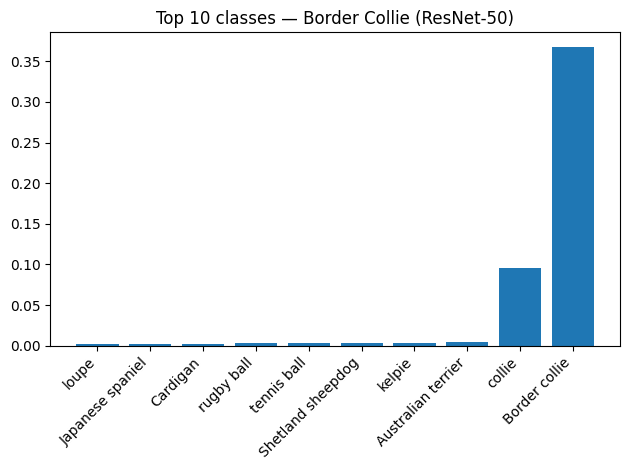

In [15]:
set_labels_resnet = list(zip(resnet_labels, list(resnet_probs.cpu().numpy())))
set_labels_resnet = sorted(set_labels_resnet, key=lambda x: x[1])

labels_resnet, probs_resnet = zip(*set_labels_resnet[-10:])

plt.bar(labels_resnet, probs_resnet)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 classes — Border Collie (ResNet-50)")
plt.tight_layout()
plt.show()